# Statistical Modeling & Risk-Based Pricing

### Import Libraries

In [1]:
import sys
from pathlib import Path
# Ensure project root is on sys.path so `import src` works when notebook is run from `notebooks/`
proj_root = Path.cwd().resolve().parent
proj_root_str = str(proj_root)
if proj_root_str not in sys.path:
    sys.path.insert(0, proj_root_str)
print('Added to sys.path:', proj_root_str)

Added to sys.path: C:\Users\teMelkishi\Desktop\projects\tenx\projects\insurance-risk-analytics


In [2]:
from src.data_loader import load_cleaned_data

from src.modeling import (
    split_data,
    label_encode_columns,
    feature_engineering,
    train_models,
    evaluate_model,
    summery_table,
    get_feature_importance,
    explain_with_shap,
    interpret_top_features,
    load_models,
)
from src.eda_utils import (
    get_categorical_columns,
)

In [5]:
# load the cleaned data
df = load_cleaned_data(file_path='../data/processed/insurance_data.csv')
df.head()

INFO:src.data_loader:Loading cleaned data from: ../data/processed/insurance_data.csv
C:\Users\teMelkishi\Desktop\projects\tenx\projects\insurance-risk-analytics\src\data_loader.py:88: DtypeWarning: Columns (0: CapitalOutstanding) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(path, parse_dates=parse_dates)
INFO:src.data_loader:✅ Cleaned data loaded successfully! Shape: (989483, 47)
INFO:src.data_loader:Columns: ['UnderwrittenCoverID', 'PolicyID', 'TransactionMonth', 'IsVATRegistered', 'LegalType', 'Title', 'Language', 'Bank', 'AccountType', 'MaritalStatus', 'Gender', 'Country', 'Province', 'PostalCode', 'MainCrestaZone', 'SubCrestaZone', 'ItemType', 'mmcode', 'VehicleType', 'RegistrationYear', 'make', 'Model', 'Cylinders', 'cubiccapacity', 'kilowatts', 'bodytype', 'NumberOfDoors', 'VehicleIntroDate', 'AlarmImmobiliser', 'TrackingDevice', 'CapitalOutstanding', 'NewVehicle', 'SumInsured', 'TermFrequency', 'CalculatedPremiumPerTerm', 'ExcessSe

,UnderwrittenCoverID,PolicyID,TransactionMonth,IsVATRegistered,LegalType,Title,Language,Bank,AccountType,MaritalStatus,...,CoverType,CoverGroup,Section,Product,StatutoryClass,StatutoryRiskType,TotalPremium,TotalClaims,Margin,LossRatio
0,145249,12827,2015-03-01,True,Close Corporation,Mr,English,First National Bank,Current account,Not specified,...,Windscreen,Comprehensive - Taxi,Motor Comprehensive,Mobility Metered Taxis: Monthly,Commercial,IFRS Constant,21.929825,0.0,21.929825,0.0
1,145249,12827,2015-05-01,True,Close Corporation,Mr,English,First National Bank,Current account,Not specified,...,Windscreen,Comprehensive - Taxi,Motor Comprehensive,Mobility Metered Taxis: Monthly,Commercial,IFRS Constant,21.929825,0.0,21.929825,0.0
2,145249,12827,2015-07-01,True,Close Corporation,Mr,English,First National Bank,Current account,Not specified,...,Windscreen,Comprehensive - Taxi,Motor Comprehensive,Mobility Metered Taxis: Monthly,Commercial,IFRS Constant,0.000000,0.0,0.000000,0.0
3,145255,12827,2015-05-01,True,Close Corporation,Mr,English,First National Bank,Current account,Not specified,...,Own Damage,Comprehensive - Taxi,Motor Comprehensive,Mobility Metered Taxis: Monthly,Commercial,IFRS Constant,512.848070,0.0,512.848070,0.0
4,145255,12827,2015-07-01,True,Close Corporation,Mr,English,First National Bank,Current account,Not specified,...,Own Damage,Comprehensive - Taxi,Motor Comprehensive,Mobility Metered Taxis: Monthly,Commercial,IFRS Constant,0.000000,0.0,0.000000,0.0


In [6]:
df = feature_engineering(df)
df.head()

✓ Created VehicleAge
✓ Created PolicyMonth, PolicyYear, PolicyDay, IsWeekendTransaction
✓ Created EngineCC_Per_KW and KW_Per_CC
✓ Created SumInsured_Log
✓ Created SumInsured_To_Excess
✓ Created MakeGroup and IsLuxuryMake
✓ Created Make_Model interaction
✓ Converted AlarmImmobiliser to binary
✓ Converted TrackingDevice to binary
✓ Converted NewVehicle to binary
✓ Converted IsVATRegistered to binary
✅ Feature engineering completed. New shape: (989483, 59)


,UnderwrittenCoverID,PolicyID,TransactionMonth,IsVATRegistered,LegalType,Title,Language,Bank,AccountType,MaritalStatus,...,PolicyYear,PolicyDay,IsWeekendTransaction,EngineCC_Per_KW,KW_Per_CC,SumInsured_Log,SumInsured_To_Excess,MakeGroup,IsLuxuryMake,Make_Model
0,145249,12827,2015-03-01,1,Close Corporation,Mr,English,First National Bank,Current account,Not specified,...,2015,1,True,19.824427,0.050038,0.009950,NaN,MERCEDES-BENZ,1,MERCEDES-BENZ_E 240
1,145249,12827,2015-05-01,1,Close Corporation,Mr,English,First National Bank,Current account,Not specified,...,2015,1,False,19.824427,0.050038,0.009950,NaN,MERCEDES-BENZ,1,MERCEDES-BENZ_E 240
2,145249,12827,2015-07-01,1,Close Corporation,Mr,English,First National Bank,Current account,Not specified,...,2015,1,False,19.824427,0.050038,0.009950,NaN,MERCEDES-BENZ,1,MERCEDES-BENZ_E 240
3,145255,12827,2015-05-01,1,Close Corporation,Mr,English,First National Bank,Current account,Not specified,...,2015,1,False,19.824427,0.050038,11.689405,NaN,MERCEDES-BENZ,1,MERCEDES-BENZ_E 240
4,145255,12827,2015-07-01,1,Close Corporation,Mr,English,First National Bank,Current account,Not specified,...,2015,1,False,19.824427,0.050038,11.689405,NaN,MERCEDES-BENZ,1,MERCEDES-BENZ_E 240


### Encode categorical variables using label encoding.

In [7]:
target = "TotalPremium"

# Columns to drop
drop_cols = [
    'UnderwrittenCoverID',
    'PolicyID',
    'PostalCode',
    'mmcode',
    'CapitalOutstanding',
    'CalculatedPremiumPerTerm',
    'TotalClaims',
    'Margin',
    'LossRatio',
    'TransactionMonth', 
    'RegistrationYear', 
    'VehicleIntroDate'
]

X = df.drop(columns=drop_cols, errors='ignore')
y = df[target]

print(f"Features kept: {X.shape[1]} columns")
print(f"Target: {target}")

Features kept: 47 columns
Target: TotalPremium


In [8]:
categorical_cols = get_categorical_columns(df)
categorical_cols = [col for col in categorical_cols if col in X.columns]

Categorical columns: ['LegalType', 'Title', 'Language', 'Bank', 'AccountType', 'MaritalStatus', 'Gender', 'Country', 'Province', 'MainCrestaZone', 'SubCrestaZone', 'ItemType', 'VehicleType', 'make', 'Model', 'bodytype', 'CapitalOutstanding', 'TermFrequency', 'CoverCategory', 'CoverType', 'CoverGroup', 'Section', 'Product', 'StatutoryClass', 'StatutoryRiskType', 'MakeGroup', 'Make_Model']


### Label Encoding

In [9]:
print("\n=== Label Encoding ===")
X_encoded, encoders = label_encode_columns(X, categorical_cols)
print(f"Encoded features shape: {X_encoded.shape}")


=== Label Encoding ===
Encoded features shape: (989483, 47)


## Spliting the data

In [10]:
print("\n=== Splitting Data ===")
X_train, X_test, y_train, y_test = split_data(X_encoded, y, test_size=0.2, random_state=42)

print(f"Train set: {X_train.shape[0]:,} rows")
print(f"Test set : {X_test.shape[0]:,} rows")


=== Splitting Data ===
Train set: 791,586 rows
Test set : 197,897 rows


### Train the models

In [11]:
# Quick fix - remove any remaining datetime columns
datetime_cols = X_train.select_dtypes(include=['datetime64']).columns.tolist()
if datetime_cols:
    print(f"Removing datetime columns: {datetime_cols}")
    X_train = X_train.drop(columns=datetime_cols)
    X_test = X_test.drop(columns=datetime_cols)

In [12]:
# === HANDLE MISSING VALUES BEFORE TRAINING ===
print("Checking for NaNs...")
print(f"NaNs in X_train: {X_train.isna().sum().sum()}")

# Fill numeric columns with median
numeric_cols = X_train.select_dtypes(include=['number']).columns
X_train[numeric_cols] = X_train[numeric_cols].fillna(X_train[numeric_cols].median())
X_test[numeric_cols] = X_test[numeric_cols].fillna(X_test[numeric_cols].median())

# Fill categorical/object columns
cat_cols = X_train.select_dtypes(include=['object']).columns
X_train[cat_cols] = X_train[cat_cols].fillna("missing")
X_test[cat_cols] = X_test[cat_cols].fillna("missing")

print("NaNs handled successfully!")

Checking for NaNs...
NaNs in X_train: 1583172
NaNs handled successfully!


In [11]:
lr_model, dt_model, rfr_model, xgb_model = train_models(X_train, y_train)

Before cleaning - NaNs in X_train: 1,583,172
✅ Final NaNs in X_train: 0
Training with 791,586 samples


### Evaluate models

In [12]:
print("\n=== Model Evaluation ===")
models = {
    "Linear Regression": lr_model,
    "Decision Tree": dt_model,
    "Random Forest": rfr_model,
    "XGBoost": xgb_model
}

results = []

for name, model in models.items():
    mae, mse, r2, y_pred = evaluate_model(model, X_test, y_test)
    rmse = mse ** 0.5
    
    results.append({
        "Model": name,
        "MAE": round(mae, 4),
        "RMSE": round(rmse, 4),
        "R²": round(r2, 4)
    })
    
    print(f"\n{name}:")
    print(f"   MAE   = {mae:,.4f}")
    print(f"   RMSE  = {rmse:,.4f}")
    print(f"   R²    = {r2:.4f}")


=== Model Evaluation ===

Linear Regression:
   MAE   = 0.0000
   RMSE  = 0.0000
   R²    = 1.0000

Decision Tree:
   MAE   = 0.0010
   RMSE  = 0.0912
   R²    = 1.0000

Random Forest:
   MAE   = 0.0019
   RMSE  = 0.4797
   R²    = 1.0000

XGBoost:
   MAE   = 0.7894
   RMSE  = 3.6563
   R²    = 0.9995


### Summary Table

In [13]:
summery_table(results)


MODEL COMPARISON
               Model     MAE    RMSE      R²
0  Linear Regression  0.0000  0.0000  1.0000
1      Decision Tree  0.0010  0.0912  1.0000
2      Random Forest  0.0019  0.4797  1.0000
3            XGBoost  0.7894  3.6563  0.9995

Results saved to 'model_comparison_results.csv'


## Feature Importance & Interpretability

In [3]:
lr_model, dt_model, rfr_model, xgb_model = load_models()


=== Model Interpretability Analysis ===

Built-in Feature Importance (XGBoost):
           Feature  Importance
34    TotalPremium    0.956603
16       Cylinders    0.019499
18       kilowatts    0.004941
14            make    0.002465
20   NumberOfDoors    0.001870
6    MaritalStatus    0.001552
24      SumInsured    0.001248
27   CoverCategory    0.001049
45    IsLuxuryMake    0.001021
5      AccountType    0.000884
41       KW_Per_CC    0.000829
9         Province    0.000774
1        LegalType    0.000664
37      PolicyYear    0.000637
10  MainCrestaZone    0.000627
Computing SHAP values... (this may take a moment)
✅ SHAP values computed successfully!


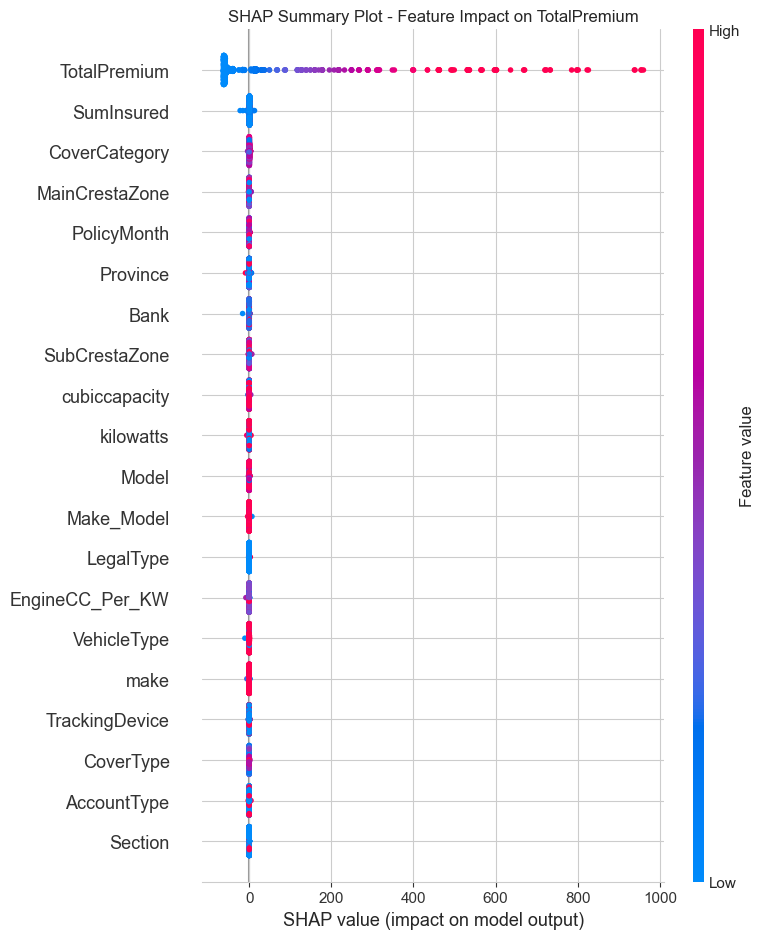

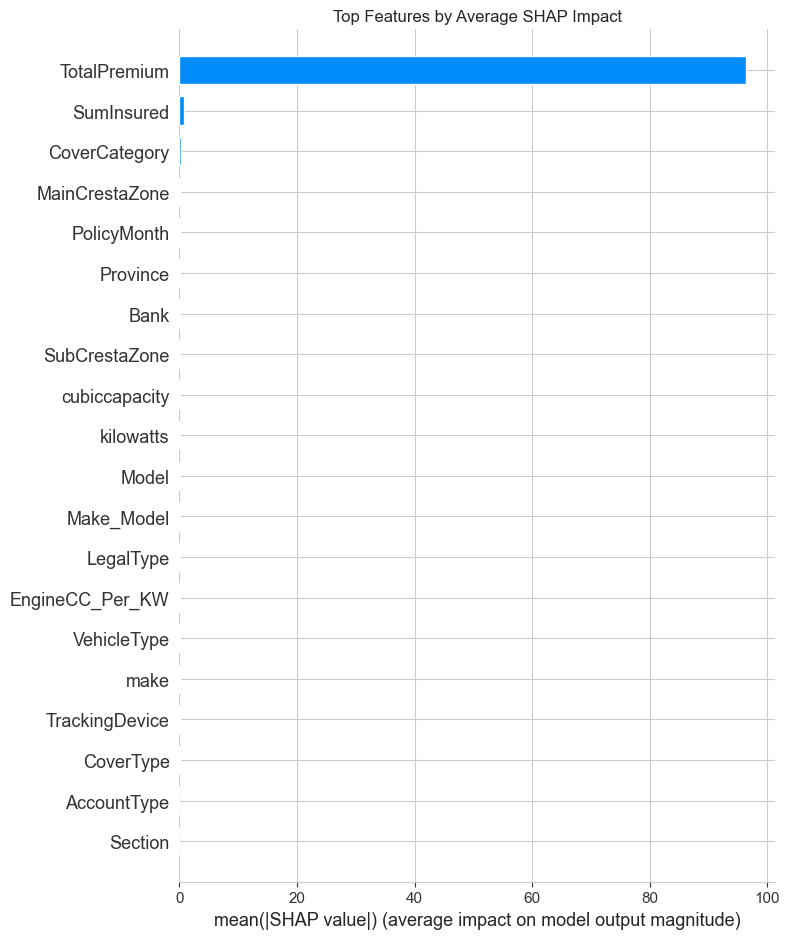


TOP 10 MOST INFLUENTIAL FEATURES FOR TotalPremium
35. TotalPremium                        → Avg Impact: 96.4641
25. SumInsured                          → Avg Impact: 0.8001
28. CoverCategory                       → Avg Impact: 0.2737
11. MainCrestaZone                      → Avg Impact: 0.1015
37. PolicyMonth                         → Avg Impact: 0.0987
10. Province                            → Avg Impact: 0.0915
 5. Bank                                → Avg Impact: 0.0733
12. SubCrestaZone                       → Avg Impact: 0.0731
18. cubiccapacity                       → Avg Impact: 0.0475
19. kilowatts                           → Avg Impact: 0.0462


In [13]:
print("\n=== Model Interpretability Analysis ===")

# Choose your best model (usually XGBoost or Random Forest)
best_model = xgb_model          # or rfr_model

# Get Feature Names
feature_names = X_train.columns.tolist()

# 1. Built-in Feature Importance
print("\nBuilt-in Feature Importance (XGBoost):")
importance_df = get_feature_importance(best_model, X_train, feature_names)
print(importance_df)

# 2. SHAP Analysis
shap_values, explainer = explain_with_shap(
    model=best_model,
    X_train=X_train,
    X_test=X_test,
    feature_names=feature_names,
    max_samples=1000   # adjust based on your RAM
)

# 3. Business Interpretation
top_features = interpret_top_features(shap_values, X_test, feature_names, top_n=10)
